<a href="https://colab.research.google.com/github/emerson-marreiros/algorithm/blob/main/Analytical_Solutions_to_the_Questionsipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **Soluções Analíticas das Questões**

In [11]:
pip install qiskit matplotlib pylatexenc

In [12]:
import os
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, Pauli, partial_trace
from qiskit.visualization import plot_bloch_multivector

# Detecção do ambiente (Jupyter/Colab/VS Code vs Script Terminal)
try:
    from IPython.display import display
    IN_NOTEBOOK = True
except ImportError:
    IN_NOTEBOOK = False


def renderizar_e_salvar(fig, nome_arquivo):
    """
    Garante a exibição da figura no ambiente de execução
    e salva uma cópia em imagem PNG no diretório atual.
    """
    # Salva a imagem em disco
    fig.savefig(nome_arquivo, bbox_inches='tight', dpi=150)

    # Exibe no ambiente apropriado
    if IN_NOTEBOOK:
        display(fig)
    else:
        plt.figure(fig.number)
        plt.show()
    plt.close(fig)


def calcular_coordenadas_bloch(sv, num_qubits):
    """
    Calcula os vetores tridimensionais (X, Y, Z) de cada qubit na Esfera de Bloch.
    """
    coordenadas = []
    for q in range(num_qubits):
        if num_qubits > 1:
            indices_para_tracar = [i for i in range(num_qubits) if i != q]
            rho = partial_trace(sv, indices_para_tracar)
            x = np.real(np.trace(np.dot(rho.data, np.array([[0, 1], [1, 0]]))))
            y = np.real(np.trace(np.dot(rho.data, np.array([[0, -1j], [1j, 0]]))))
            z = np.real(np.trace(np.dot(rho.data, np.array([[1, 0], [0, -1]]))))
        else:
            x = np.real(sv.expectation_value(Pauli('X')))
            y = np.real(sv.expectation_value(Pauli('Y')))
            z = np.real(sv.expectation_value(Pauli('Z')))

        coordenadas.append((x, y, z))
    return coordenadas


In [19]:
# ==========================================
# QUESTÕES DE 1 QUBIT (2, 3, 4, 5)
# ==========================================

def executar_circuito_1qubit(nome, estado_inicial, portas):
    qc = QuantumCircuit(1)

    if estado_inicial == 1:
        qc.x(0)
    qc.barrier()

    for porta in portas:
        if porta == 'X':
            qc.x(0)
        elif porta == 'Z':
            qc.z(0)
        elif porta == 'H':
            qc.h(0)
        qc.barrier()

    sv_final = Statevector.from_instruction(qc)

    print(f"\n==========================================")
    print(f"               {nome}")
    print(f"==========================================")
    print("Vetor de Estado Final:")
    print(np.round(sv_final.data, 4))
    print("Probabilidades [P(0), P(1)]:", np.round(sv_final.probabilities(), 4))

    # Posições de cada qubit na Esfera de Bloch
    coords = calcular_coordenadas_bloch(sv_final, 1)
    x, y, z = coords[0]
    print(f"Posição do Qubit na Esfera de Bloch (X, Y, Z): ({x:.3f}, {y:.3f}, {z:.3f})")

    # 1. Desenhar circuito colorido
    try:
        fig_circ = qc.draw(output='mpl', style='iqp')
        fig_circ.suptitle(f"Circuito - {nome}", fontsize=12)
        renderizar_e_salvar(fig_circ, f"{nome.replace(' ', '_')}_circuito.png")
    except Exception as e:
        print("Aviso: Para visualização gráfica 'mpl', instale o 'pylatexenc'. Exibindo circuito em texto:")
        print(qc.draw(output='text'))

    # 2. Desenhar Esfera de Bloch
    fig_bloch = plot_bloch_multivector(sv_final, title=f"Esfera de Bloch - {nome}")
    renderizar_e_salvar(fig_bloch, f"{nome.replace(' ', '_')}_bloch.png")


# ==========================================
# QUESTÕES DE 2 QUBITS (6 a 12)
# ==========================================

def executar_circuito_2qubits(nome, instrucoes):
    qc = QuantumCircuit(2)

    for inst in instrucoes:
        if inst == 'XX':
            qc.x(0)
            qc.x(1)
        elif inst == 'ZZ':
            qc.z(0)
            qc.z(1)
        elif inst == 'HH':
            qc.h(0)
            qc.h(1)
        elif inst == 'XZ':
            qc.z(0)
            qc.x(1)
        elif inst == 'XH':
            qc.h(0)
            qc.x(1)
        elif inst == 'HX':
            qc.x(0)
            qc.h(1)
        elif inst == 'CNOT_01':
            qc.cx(0, 1)
        elif inst == 'CNOT_10':
            qc.cx(1, 0)
        elif inst == 'XI':
            qc.x(1)
        qc.barrier()

    sv_final = Statevector.from_instruction(qc)

    print(f"\n==========================================")
    print(f"               {nome}")
    print(f"==========================================")
    print("Vetor de Estado Final:")
    print(np.round(sv_final.data, 4))
    print("Probabilidades [P(00), P(01), P(10), P(11)]:", np.round(sv_final.probabilities(), 4))

    coords = calcular_coordenadas_bloch(sv_final, 2)
    print("Posição dos Qubits na Esfera de Bloch (X, Y, Z):")
    for q_idx, (x, y, z) in enumerate(coords):
        raio = np.sqrt(x**2 + y**2 + z**2)
        print(f"  Qubit {q_idx}: ({x:.3f}, {y:.3f}, {z:.3f}) | Raio = {raio:.3f}")
        if raio < 0.99:
            print(f"    -> Qubit {q_idx} está emaranhado (vetor reduzido na esfera).")

    # 1. Desenhar circuito colorido
    try:
        fig_circ = qc.draw(output='mpl', style='iqp')
        fig_circ.suptitle(f"Circuito - {nome}", fontsize=12)
        renderizar_e_salvar(fig_circ, f"{nome.replace(' ', '_')}_circuito.png")
    except Exception as e:
        print("Aviso: Para visualização gráfica 'mpl', instale o 'pylatexenc'. Exibindo circuito em texto:")
        print(qc.draw(output='text'))

    # 2. Desenhar Esfera de Bloch (2 qubits)
    fig_bloch = plot_bloch_multivector(sv_final, title=f"Esfera de Bloch - {nome}")
    renderizar_e_salvar(fig_bloch, f"{nome.replace(' ', '_')}_bloch.png")

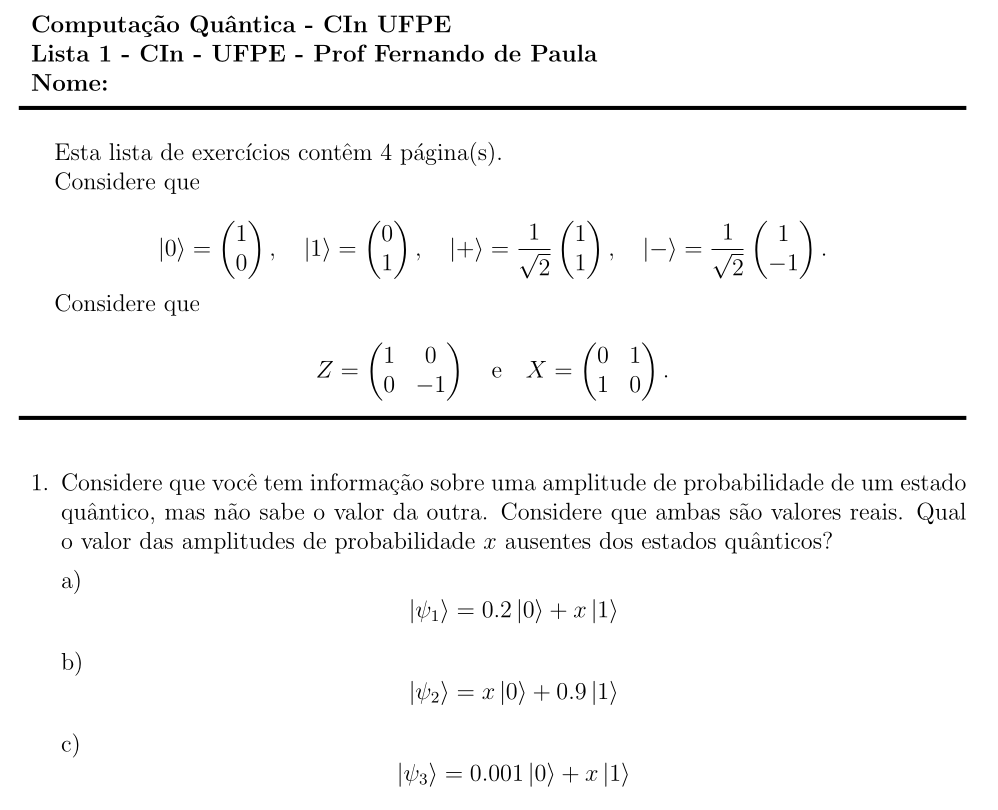

### Resposta Q-1. Amplitudes de Probabilidade Ausentes

Para um estado quântico $\vert\psi\rangle = \alpha\vert 0\rangle + \beta\vert 1\rangle$ ser válido, a condição de normalização exige que $\vert{}\alpha\vert{}^2 + \vert{}\beta\vert{}^2 = 1$.

a) $\vert{}\psi_1\rangle = 0.2\vert 0\rangle + x\vert 1\rangle$   

Solução: $$(0.2)^2 + x^2 = 1 \implies 0.04 + x^2 = 1 \implies x^2 = 0.96 \implies x = \pm\sqrt{0.96} \approx \pm 0.9798$$

b) $\vert{}\psi_2\rangle = x\vert 0\rangle + 0.9\vert 1\rangle$   

Solução: $$x^2 + (0.9)^2 = 1 \implies x^2 + 0.81 = 1 \implies x^2 = 0.19 \implies x = \pm\sqrt{0.19} \approx \pm 0.4359$$

c) $\vert{}\psi_3\rangle = 0.001\vert 0\rangle + x\vert 1\rangle$   

Solução: $$(0.001)^2 + x^2 = 1 \implies 10^{-6} + x^2 = 1 \implies x = \pm\sqrt{0.999999} \approx \pm 0.9999995$$

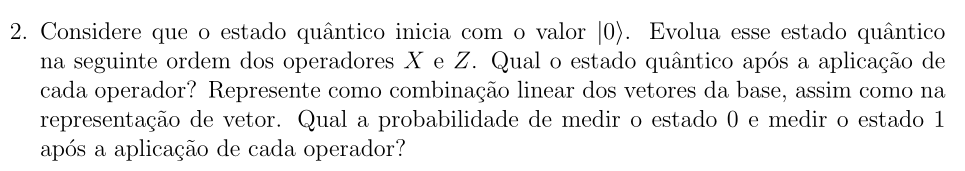


               Questão 2
Vetor de Estado Final:
[ 0.+0.j -1.+0.j]
Probabilidades [P(0), P(1)]: [0. 1.]
Posição do Qubit na Esfera de Bloch (X, Y, Z): (0.000, 0.000, -1.000)


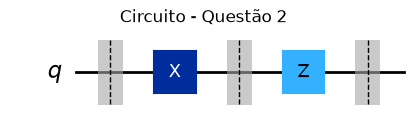

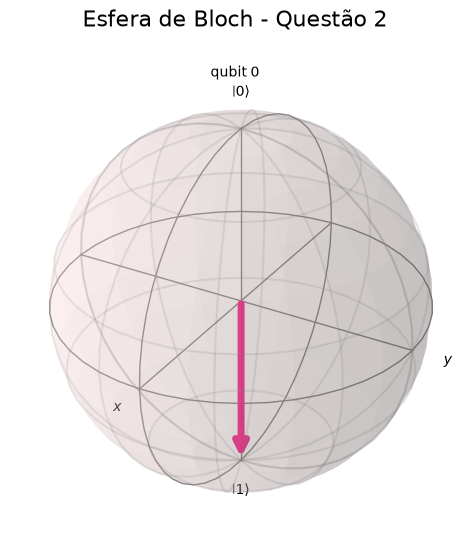

In [20]:
# Execução Questões 2
executar_circuito_1qubit("Questão 2", estado_inicial=0, portas=['X', 'Z'])


### Resposta Q-2. Evolução de Estado Iniciando em $\vert{}0\rangle$ com Operadores $X$ e $Z$   

- Estado Inicial: $\vert 0\rangle = \begin{pmatrix}1\\0\end{pmatrix}$. $P(0) = 1$, $P(1) = 0$.   

- Após $X$: $X\vert 0\rangle = \vert 1\rangle = \begin{pmatrix}0\\1\end{pmatrix}$.   

- Probabilidades: $P(0) = 0$, $P(1) = 1$.

- Após $Z$: $Z\vert 1\rangle = -\vert 1\rangle = 0\vert 0\rangle - 1\vert 1\rangle = \begin{pmatrix}0\\-1\end{pmatrix}$.   

- Probabilidades: $P(0) = 0$, $P(1) = \vert{}-1\vert{}^2 = 1$.

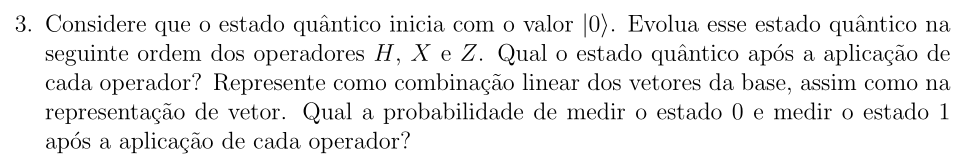

### Resposta Q-3. Evolução de Estado Iniciando em $\vert{}0\rangle$ com Operadores $H, X, Z$   

- Estado Inicial: $\vert 0\rangle = \begin{pmatrix}1\\0\end{pmatrix}$. $P(0) = 1$, $P(1) = 0$.   

- Após $H$: $H\vert 0\rangle = \vert +\rangle = \frac{1}{\sqrt{2}}\vert 0\rangle + \frac{1}{\sqrt{2}}\vert 1\rangle = \frac{1}{\sqrt{2}}\begin{pmatrix}1\\1\end{pmatrix}$.   

- Probabilidades: $P(0) = 0.5$, $P(1) = 0.5$.

- Após $X$: $X\vert +\rangle = \vert +\rangle = \frac{1}{\sqrt{2}}\vert 0\rangle + \frac{1}{\sqrt{2}}\vert 1\rangle = \frac{1}{\sqrt{2}}\begin{pmatrix}1\\1\end{pmatrix}$.   
- Probabilidades: $P(0) = 0.5$, $P(1) = 0.5$.

- Após $Z$: $Z\vert +\rangle = \vert -\rangle = \frac{1}{\sqrt{2}}\vert 0\rangle - \frac{1}{\sqrt{2}}\vert 1\rangle = \frac{1}{\sqrt{2}}\begin{pmatrix}1\\-1\end{pmatrix}$.   
- Probabilidades: $P(0) = 0.5$, $P(1) = 0.5$.


               Questão 3
Vetor de Estado Final:
[ 0.7071+0.j -0.7071+0.j]
Probabilidades [P(0), P(1)]: [0.5 0.5]
Posição do Qubit na Esfera de Bloch (X, Y, Z): (-1.000, 0.000, 0.000)


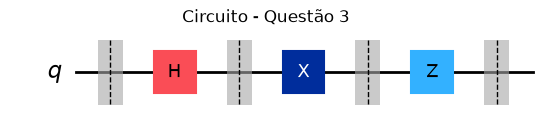

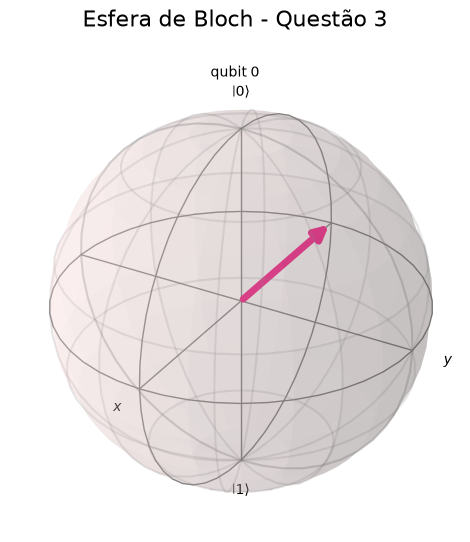

In [21]:
executar_circuito_1qubit("Questão 3", estado_inicial=0, portas=['H', 'X', 'Z'])


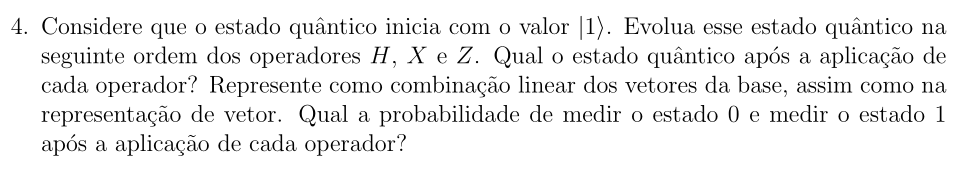

### Resposta Q-4. Evolução de Estado Iniciando em $\vert{}1\rangle$ com Operadores $H, X, Z$   

Estado Inicial: $\vert 1\rangle = \begin{pmatrix}0\\1\end{pmatrix}$. $P(0) = 0$, $P(1) = 1$.   

- Após $H$: $H\vert 1\rangle = \vert -\rangle = \frac{1}{\sqrt{2}}\vert 0\rangle - \frac{1}{\sqrt{2}}\vert 1\rangle = \frac{1}{\sqrt{2}}\begin{pmatrix}1\\-1\end{pmatrix}$.   
- Probabilidades: $P(0) = 0.5$, $P(1) = 0.5$.

- Após $X$: $X\vert -\rangle = -\vert -\rangle = -\frac{1}{\sqrt{2}}\vert 0\rangle + \frac{1}{\sqrt{2}}\vert 1\rangle = \frac{1}{\sqrt{2}}\begin{pmatrix}-1\\1\end{pmatrix}$.   
- Probabilidades: $P(0) = 0.5$, $P(1) = 0.5$.

- Após $Z$: $Z(-\vert -\rangle) = -\vert +\rangle = -\frac{1}{\sqrt{2}}\vert 0\rangle - \frac{1}{\sqrt{2}}\vert 1\rangle = \frac{1}{\sqrt{2}}\begin{pmatrix}-1\\-1\end{pmatrix}$.   
- Probabilidades: $P(0) = 0.5$, $P(1) = 0.5$.


               Questão 4
Vetor de Estado Final:
[-0.7071+0.j -0.7071+0.j]
Probabilidades [P(0), P(1)]: [0.5 0.5]
Posição do Qubit na Esfera de Bloch (X, Y, Z): (1.000, 0.000, 0.000)


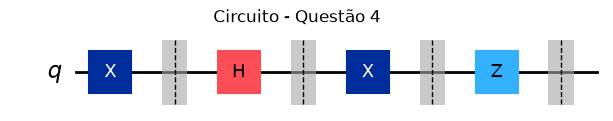

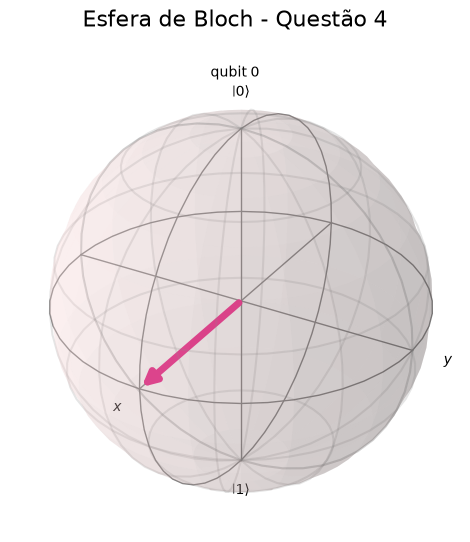

In [22]:
executar_circuito_1qubit("Questão 4", estado_inicial=1, portas=['H', 'X', 'Z'])


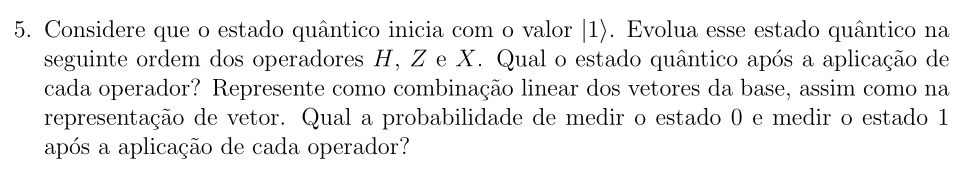

### Resposta Q-5. Evolução de Estado Iniciando em $\vert{}1\rangle$ com Operadores $H, Z, X$   

- Estado Inicial: $\vert 1\rangle = \begin{pmatrix}0\\1\end{pmatrix}$. $P(0) = 0$, $P(1) = 1$.   

- Após $H$: $H\vert 1\rangle = \vert -\rangle = \frac{1}{\sqrt{2}}\begin{pmatrix}1\\-1\end{pmatrix}$.   
- Probabilidades: $P(0) = 0.5$, $P(1) = 0.5$.

- Após $Z$: $Z\vert -\rangle = \vert +\rangle = \frac{1}{\sqrt{2}}\begin{pmatrix}1\\1\end{pmatrix}$.   
- Probabilidades: $P(0) = 0.5$, $P(1) = 0.5$.

- Após $X$: $X\vert +\rangle = \vert +\rangle = \frac{1}{\sqrt{2}}\begin{pmatrix}1\\1\end{pmatrix}$.   
- Probabilidades: $P(0) = 0.5$, $P(1) = 0.5$.


               Questão 5
Vetor de Estado Final:
[0.7071+0.j 0.7071+0.j]
Probabilidades [P(0), P(1)]: [0.5 0.5]
Posição do Qubit na Esfera de Bloch (X, Y, Z): (1.000, 0.000, 0.000)


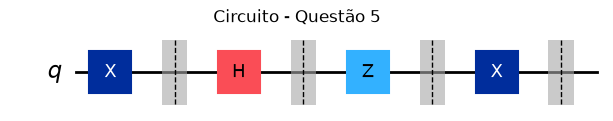

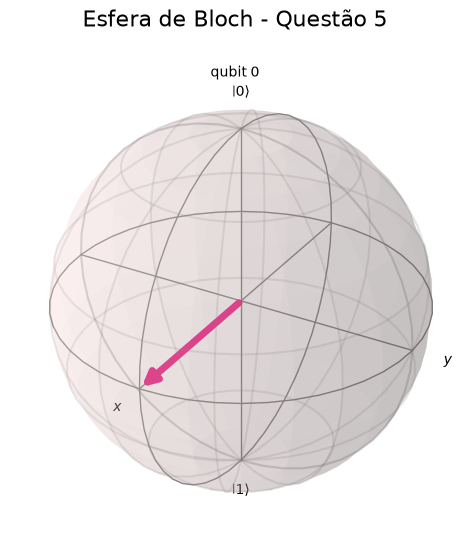

In [23]:
executar_circuito_1qubit("Questão 5", estado_inicial=1, portas=['H', 'Z', 'X'])

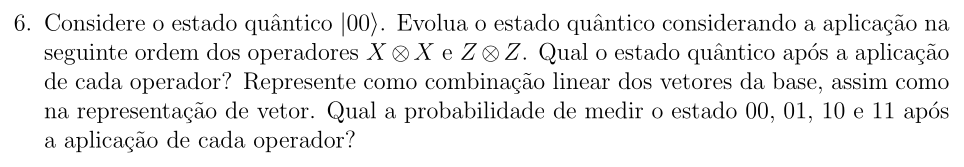

### Resposta Q-6. Evolução de $\vert{}00\rangle$ com $X\otimes X$ e $Z\otimes Z$   

- Estado Inicial: $\vert 00\rangle = \begin{pmatrix}1&0&0&0\end{pmatrix}^T$. $P(00)=1$.   

- Após $X \otimes X$: $(X\vert 0\rangle) \otimes (X\vert 0\rangle) = \vert 11\rangle = \begin{pmatrix}0&0&0&1\end{pmatrix}^T$.   

- Probabilidades: $P(11) = 1$, outras = $0$.

- Após $Z \otimes Z$: $(Z\vert 1\rangle) \otimes (Z\vert 1\rangle) = (-\vert 1\rangle) \otimes (-\vert 1\rangle) = \vert 11\rangle = \begin{pmatrix}0&0&0&1\end{pmatrix}^T$.
- Probabilidades: $P(11) = 1$, outras = $0$.


               Questão 6
Vetor de Estado Final:
[0.+0.j 0.+0.j 0.+0.j 1.+0.j]
Probabilidades [P(00), P(01), P(10), P(11)]: [0. 0. 0. 1.]
Posição dos Qubits na Esfera de Bloch (X, Y, Z):
  Qubit 0: (0.000, 0.000, -1.000) | Raio = 1.000
  Qubit 1: (0.000, 0.000, -1.000) | Raio = 1.000


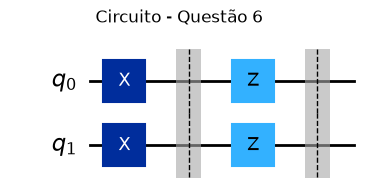

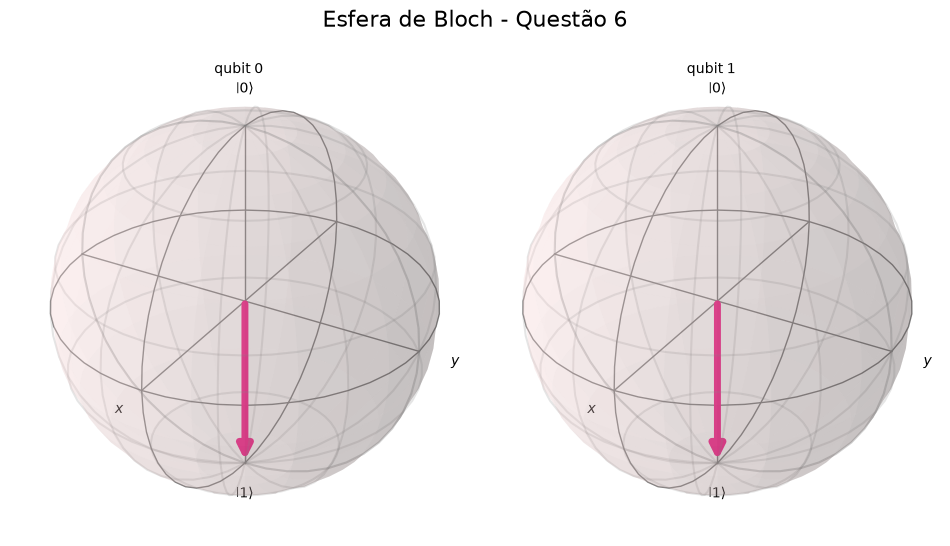

In [24]:
# Execução Questões 6
executar_circuito_2qubits("Questão 6", ['XX', 'ZZ'])

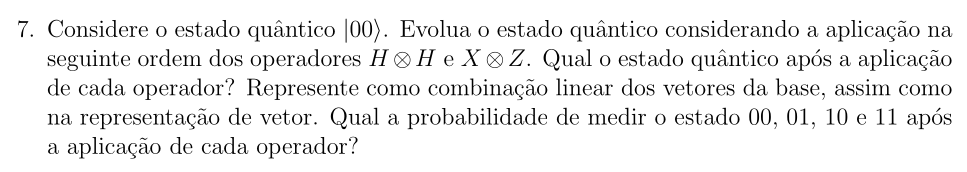

### Q-7. Evolução de $\vert{}00\rangle$ com $H\otimes H$ e $X\otimes Z$   

- Estado Inicial: $\vert 00\rangle$. $P(00)=1$.   

- Após $H \otimes H$: $\vert ++\rangle = \frac{1}{2}(\vert 00\rangle + \vert 01\rangle + \vert 10\rangle + \vert 11\rangle) = \frac{1}{2}\begin{pmatrix}1&1&1&1\end{pmatrix}^T$.   

- Probabilidades: $P(00) = P(01) = P(10) = P(11) = 0.25$.

- Após $X \otimes Z$: $(X\vert +\rangle) \otimes (Z\vert +\rangle) = \vert +\rangle \otimes \vert -\rangle = \frac{1}{2}(\vert 00\rangle - \vert 01\rangle + \vert 10\rangle - \vert 11\rangle) = \frac{1}{2}\begin{pmatrix}1&-1&1&-1\end{pmatrix}^T$.   

- Probabilidades: $P(00) = P(01) = P(10) = P(11) = 0.25$.


               Questão 7
Vetor de Estado Final:
[ 0.5+0.j -0.5+0.j  0.5+0.j -0.5+0.j]
Probabilidades [P(00), P(01), P(10), P(11)]: [0.25 0.25 0.25 0.25]
Posição dos Qubits na Esfera de Bloch (X, Y, Z):
  Qubit 0: (-1.000, 0.000, 0.000) | Raio = 1.000
  Qubit 1: (1.000, 0.000, 0.000) | Raio = 1.000


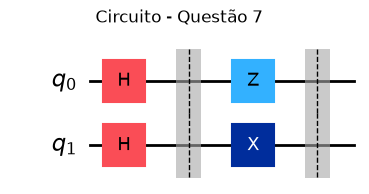

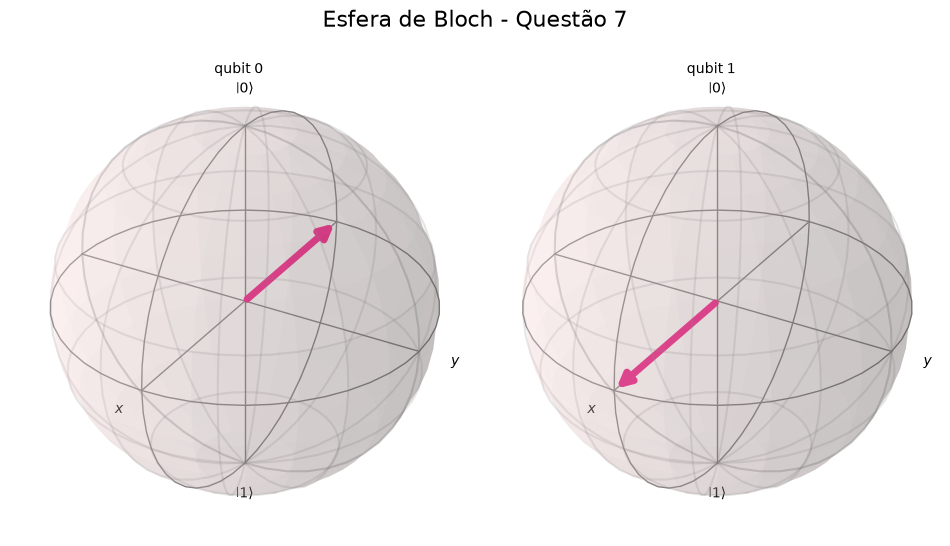

In [25]:
executar_circuito_2qubits("Questão 7", ['HH', 'XZ'])

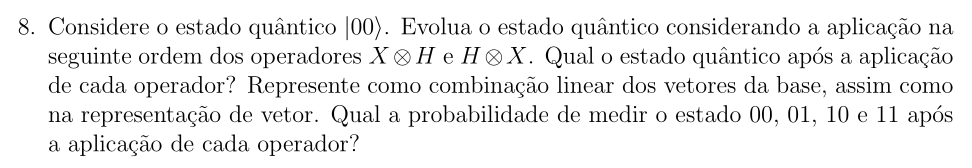

### Resposta Q-8. Evolução de $\vert{}00\rangle$ com $X\otimes H$ e $H\otimes X$   

- Estado Inicial: $\vert 00\rangle$.   

- Após $X \otimes H$: $\vert 1+\rangle = \frac{1}{\sqrt{2}}(\vert 10\rangle + \vert 11\rangle) = \frac{1}{\sqrt{2}}\begin{pmatrix}0&0&1&1\end{pmatrix}^T$.   

- Probabilidades: $P(10) = 0.5$, $P(11) = 0.5$.

- Após $H \otimes X$: $(H\vert 1\rangle) \otimes (X\vert +\rangle) = \vert -\rangle \otimes \vert +\rangle = \frac{1}{2}(\vert 00\rangle + \vert 01\rangle - \vert 10\rangle - \vert 11\rangle) = \frac{1}{2}\begin{pmatrix}1&1&-1&-1\end{pmatrix}^T$.   

- Probabilidades: $P(00) = P(01) = P(10) = P(11) = 0.25$.


               Questão 8
Vetor de Estado Final:
[ 0.5+0.j  0.5+0.j -0.5+0.j -0.5+0.j]
Probabilidades [P(00), P(01), P(10), P(11)]: [0.25 0.25 0.25 0.25]
Posição dos Qubits na Esfera de Bloch (X, Y, Z):
  Qubit 0: (1.000, 0.000, 0.000) | Raio = 1.000
  Qubit 1: (-1.000, 0.000, 0.000) | Raio = 1.000


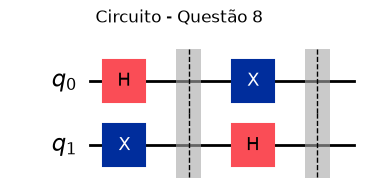

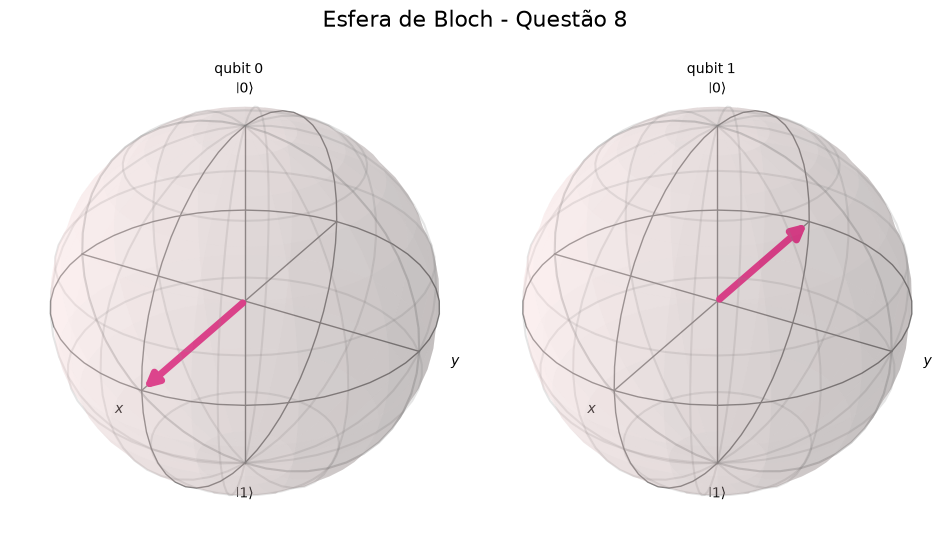

In [26]:
executar_circuito_2qubits("Questão 8", ['XH', 'HX'])

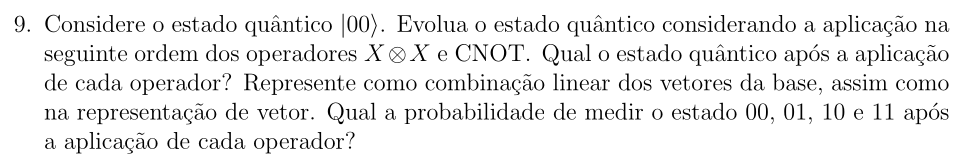

### Resposta Q-9. Evolução de $\vert{}00\rangle$ com $X\otimes X$ e CNOTEstado

- Inicial: $\vert 00\rangle$.   

- Após $X \otimes X$: $\vert 11\rangle = \begin{pmatrix}0&0&0&1\end{pmatrix}^T$.  

  - Probabilidades: $P(11) = 1$.
  
- Após $\text{CNOT}$ (com controle no qubit 0): $\text{CNOT}\vert 11\rangle = \vert 01\rangle$ (na convenção Qiskit $\vert q_1 q_0\rangle$).   

  - Probabilidades: $P(01) = 1$, outras = $0$.


               Questão 9
Vetor de Estado Final:
[0.+0.j 1.+0.j 0.+0.j 0.+0.j]
Probabilidades [P(00), P(01), P(10), P(11)]: [0. 1. 0. 0.]
Posição dos Qubits na Esfera de Bloch (X, Y, Z):
  Qubit 0: (0.000, 0.000, -1.000) | Raio = 1.000
  Qubit 1: (0.000, 0.000, 1.000) | Raio = 1.000


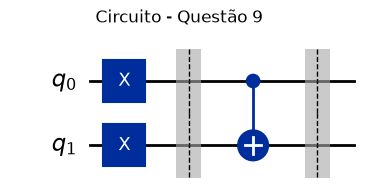

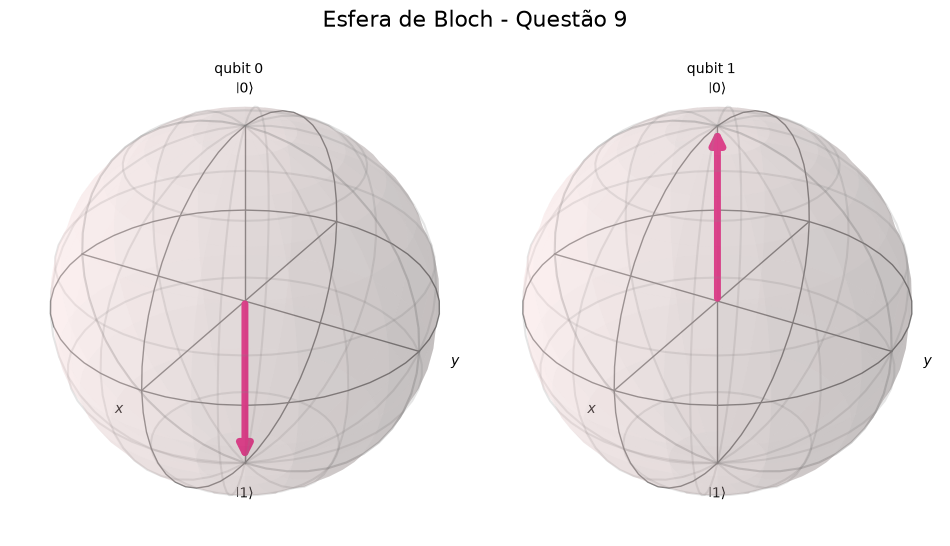

In [27]:
executar_circuito_2qubits("Questão 9", ['XX', 'CNOT_01'])

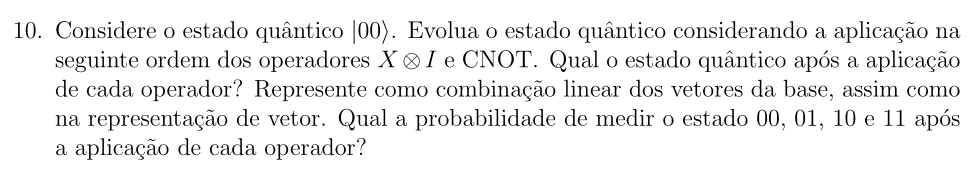

### Resposta Q-10. Evolução de $\vert{}00\rangle$ com $X\otimes I$ e CNOTEstado

- Inicial: $\vert 00\rangle$.   

- Após $X \otimes I$: $(X\vert 0\rangle) \otimes \vert 0\rangle = \vert 10\rangle = \begin{pmatrix}0&0&1&0\end{pmatrix}^T$.   

   - Probabilidades: $P(10) = 1$.
   
- Após $\text{CNOT}$ (com controle no qubit 1): $\text{CNOT}\vert 10\rangle = \vert 11\rangle = \begin{pmatrix}0&0&0&1\end{pmatrix}^T$.   

   - Probabilidades: $P(11) = 1$, outras = $0$.


               Questão 10
Vetor de Estado Final:
[0.+0.j 0.+0.j 0.+0.j 1.+0.j]
Probabilidades [P(00), P(01), P(10), P(11)]: [0. 0. 0. 1.]
Posição dos Qubits na Esfera de Bloch (X, Y, Z):
  Qubit 0: (0.000, 0.000, -1.000) | Raio = 1.000
  Qubit 1: (0.000, 0.000, -1.000) | Raio = 1.000


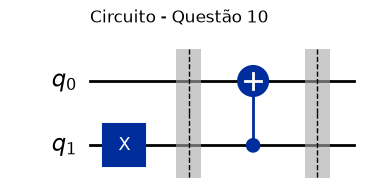

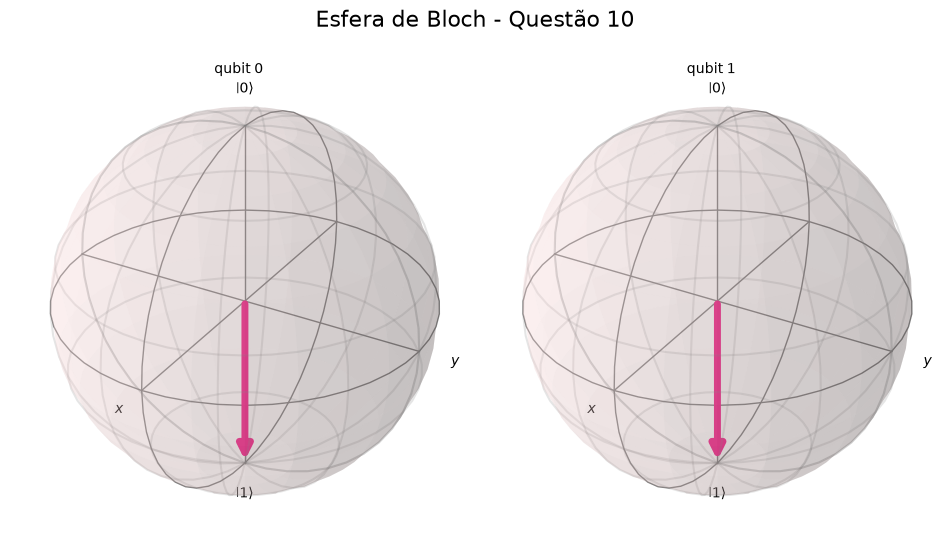

In [28]:
executar_circuito_2qubits("Questão 10", ['XI', 'CNOT_10'])

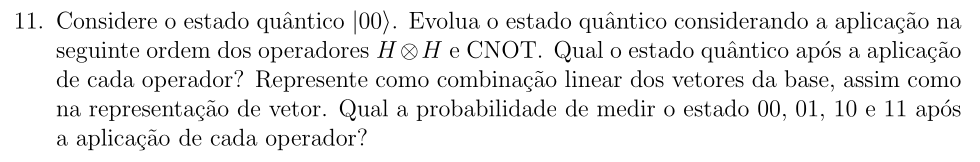

### Resposta Q-11. Evolução de $\vert{}00\rangle$ com $H\otimes H$ e CNOT

- Estado Inicial: $\vert 00\rangle$.   

Após $H \otimes H$: $\vert ++\rangle = \frac{1}{2}(\vert 00\rangle + \vert 01\rangle + \vert 10\rangle + \vert 11\rangle)$.   
  - Probabilidades: $P(00) = P(01) = P(10) = P(11) = 0.25$.
   
Após CNOT: A porta CNOT permuta $\vert 01\rangle \leftrightarrow \vert 11\rangle$, mas como ambas têm o mesmo coeficiente ($\frac{1}{2}$), o estado permanece $\vert ++\rangle$.   

- Probabilidades: $P(00) = P(01) = P(10) = P(11) = 0.25$.


               Questão 11
Vetor de Estado Final:
[0.5+0.j 0.5+0.j 0.5+0.j 0.5+0.j]
Probabilidades [P(00), P(01), P(10), P(11)]: [0.25 0.25 0.25 0.25]
Posição dos Qubits na Esfera de Bloch (X, Y, Z):
  Qubit 0: (1.000, 0.000, 0.000) | Raio = 1.000
  Qubit 1: (1.000, 0.000, 0.000) | Raio = 1.000


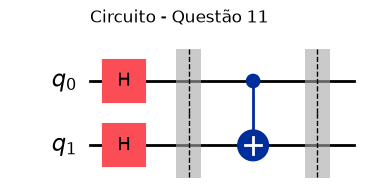

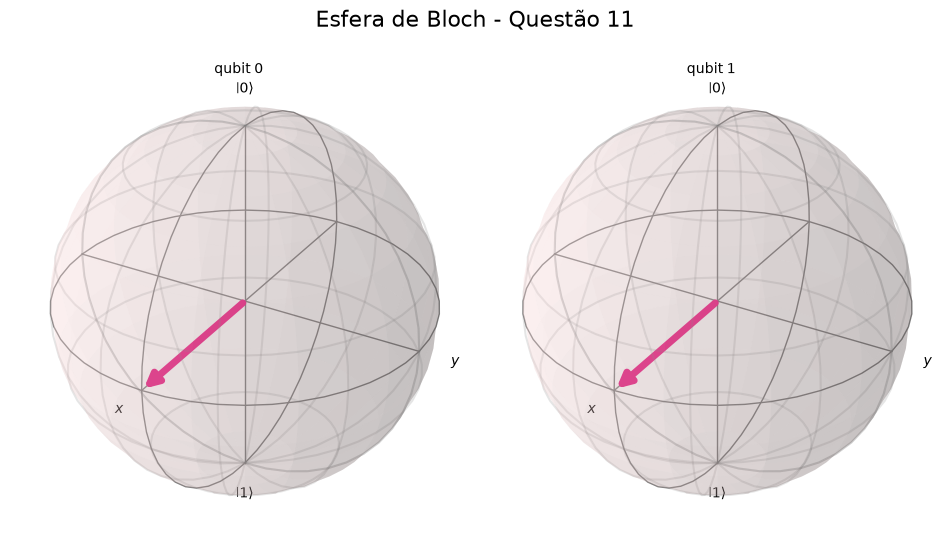

In [29]:
executar_circuito_2qubits("Questão 11", ['HH', 'CNOT_01'])

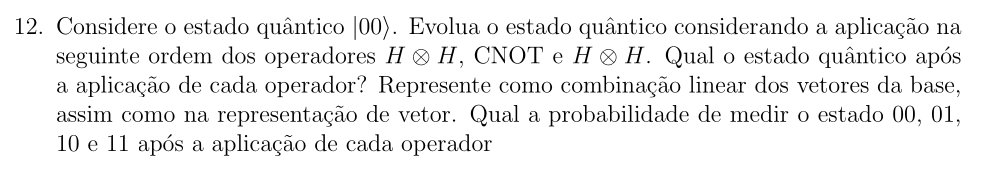

### Resposta Q-12. Evolução de $\vert{}00\rangle$ com $H\otimes H$, CNOT e $H\otimes H$   

- Após $H \otimes H$: $\vert ++\rangle$.
  - Probabilidades = $0.25$ cada.   
- Após CNOT: $\vert ++\rangle$.

  - Probabilidades = $0.25$ cada.   
  
- Após $H \otimes H$ final: $(H \otimes H)\vert ++\rangle = \vert 00\rangle = \begin{pmatrix}1&0&0&0\end{pmatrix}^T$.   

  - Probabilidades: $P(00) = 1$, outras = $0$.


               Questão 12
Vetor de Estado Final:
[1.+0.j 0.+0.j 0.+0.j 0.+0.j]
Probabilidades [P(00), P(01), P(10), P(11)]: [1. 0. 0. 0.]
Posição dos Qubits na Esfera de Bloch (X, Y, Z):
  Qubit 0: (0.000, 0.000, 1.000) | Raio = 1.000
  Qubit 1: (0.000, 0.000, 1.000) | Raio = 1.000


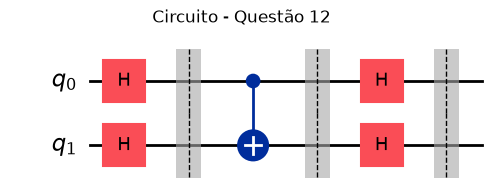

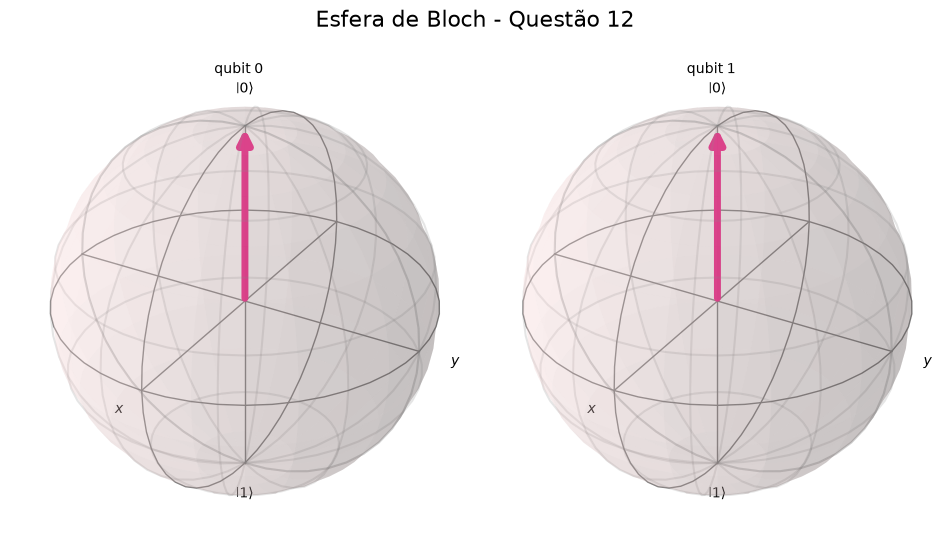

In [30]:
executar_circuito_2qubits("Questão 12", ['HH', 'CNOT_01', 'HH'])